<h1>Первая практическая, исследование временных рядов</h1>

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

In [80]:
df = pd.read_csv("HH Spot Price.csv")
df.head()

,Unnamed: 0,"Henry Hub Natural Gas Spot Price, Monthly (Dollars per Million Btu)"
0,1997 01,3.45
1,1997 02,2.15
2,1997 03,1.89
3,1997 04,2.03
4,1997 05,2.25


<h2>Предобработка</h2>

In [81]:
df.columns=["Month", "SpotPrice"]

In [82]:
df.set_index('Month', inplace=True)

df.tail()

,SpotPrice
Month,
2020 11,2.61
2020 12,2.59
2021 01,2.71
2021 02,5.35
2021 03,2.62


In [83]:
df.head()

,SpotPrice
Month,
1997 01,3.45
1997 02,2.15
1997 03,1.89
1997 04,2.03
1997 05,2.25


Сделаем дату индексом

In [84]:
df.index = pd.to_datetime(df.index)

df.index[:5]

C:\Users\ivans\AppData\Local\Temp\ipykernel_12952\3144127074.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


DatetimeIndex(['1997-01-01', '1997-02-01', '1997-03-01', '1997-04-01',
               '1997-05-01'],
              dtype='datetime64[ns]', name='Month', freq=None)

посмотрим наличие пропусков

In [85]:
has_nan = df.isnull().any()
print(has_nan)

SpotPrice    False
dtype: bool


Ураааа нет пропусков

Посмотрим наличие выбросов

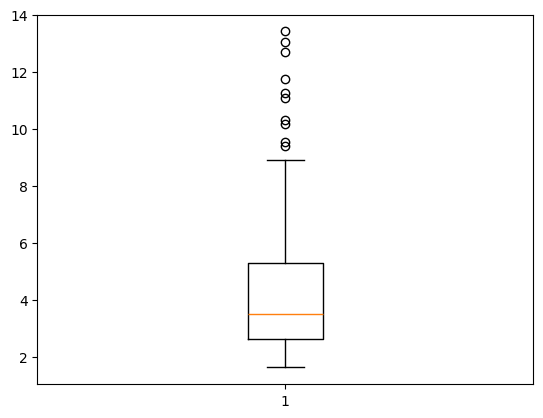

In [86]:
plt.boxplot(df)
plt.show()

Они есть, неудача

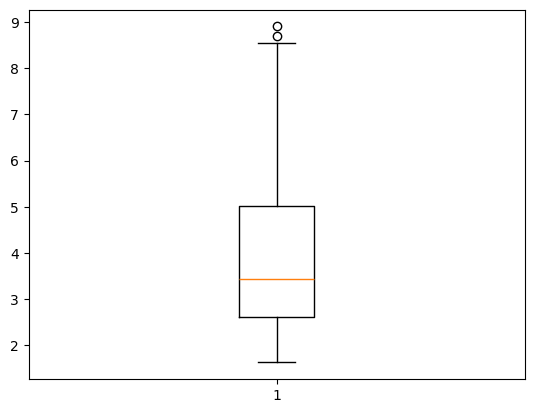

In [87]:
# Рассчитываем квартили
Q1 = df['SpotPrice'].quantile(0.25)
Q3 = df['SpotPrice'].quantile(0.75)
IQR = Q3 - Q1

# Определяем границы
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Удаляем выбросы
df_cleaned = df[(df['SpotPrice'] >= lower_bound) & (df['SpotPrice'] <= upper_bound)]
plt.boxplot(df_cleaned)
plt.show()

In [88]:
df = df_cleaned

Теперь выбросов нет, все хорошо

<h2>Анализ</h2>

C:\Users\ivans\AppData\Local\Temp\ipykernel_12952\795857893.py:2: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'YE-DEC' instead.
  years = pd.date_range(start='1997-01', end='2021-01', freq='A-DEC')


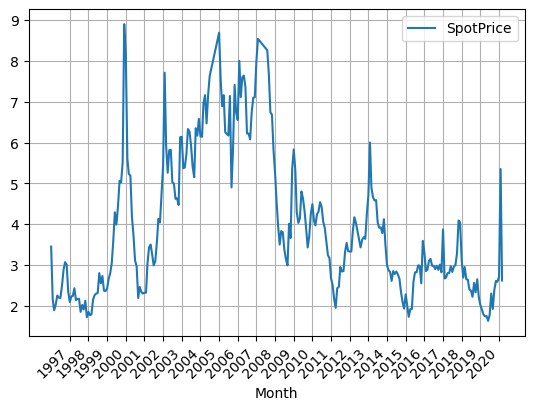

In [89]:

df.plot()
years = pd.date_range(start='1997-01', end='2021-01', freq='A-DEC')
plt.xticks(years, years.year, rotation=45)
plt.grid(True)
plt.show()

In [90]:
result = adfuller(df)

In [91]:
if (result[0]<((result[4]).get('5%'))):
    print("ряд стационарен")
else: 
    print("ряд нестационарен")

ряд нестационарен


In [92]:
if (result[0]<((result[4]).get('10%'))):
    print("ряд можно считать стационарным")
else: 
    print("ряд точно нестационарен")

ряд точно нестационарен


Как можем видеть, ряд совсем не стационарен

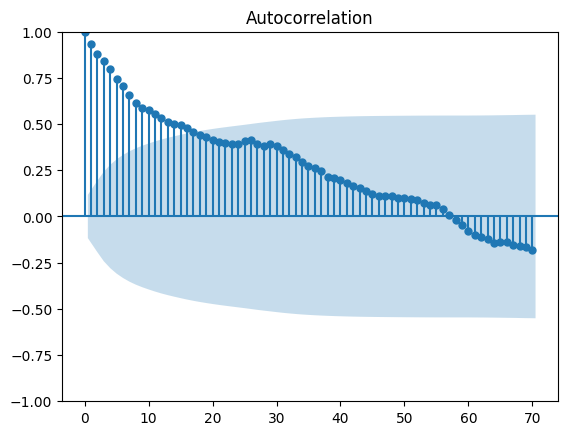

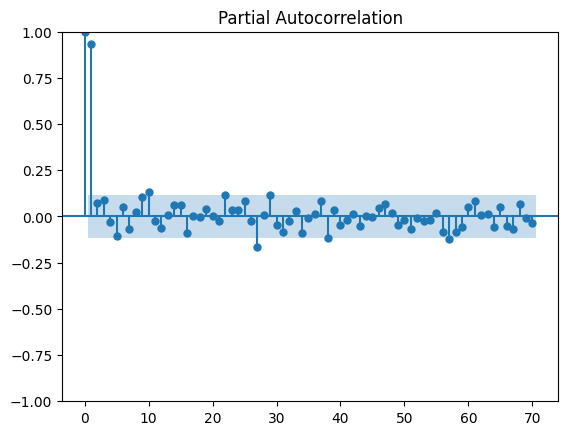

In [93]:
plot_acf(df, lags=70)  # ACF
plot_pacf(df, lags=70)  # PACF
plt.show()

***Соответственно, исходя из графиков, для моделей параметр будет равен q=17, а p=2.***

In [94]:

def differing(data,sch):
    result = adfuller(data)
    sch+=1
    #если ряд стационарен
    if (result[0]<((result[4]).get('5%'))):
        return sch

    #если ряд не стационарен
    else:
        data_diff = data.diff().dropna()
        return differing(data,sch)
sch=0
kkk=differing(df,sch)
print(sch)

RecursionError: maximum recursion depth exceeded

блиин, рекурскией не вышло(((

In [95]:
OK=0
sch=0
data_diff=df
while(OK!=1):
    result = adfuller(data_diff)
    sch+=1
    if (result[0]<((result[4]).get('5%'))):
        OK=1
    else:
        data_diff = data_diff.diff().dropna()

print(sch)

2


Получается нам надо продифференциорвать всего 2 раза, чтобы функция стала стационарной

***Чтош, ввиду того, что у нас ряд изначально не стационарный, модели ma и arma использовать нам не придется***

<h2>Обучение моделей</h2>

In [321]:
p=2
q=17
d=2

In [322]:
AR = AutoReg(df, lags=p).fit() #p=2
ARIMAA = ARIMA(df, order=(p,d,q)).fit()
AR_predictt = AR.predict(start=len(df), end=len(df) + 24)
ARIMA_predictt = ARIMAA.predict(start=len(df), end=len(df) + 24)
AR_predict = AR_predictt.to_frame()
ARIMA_predict = ARIMA_predictt.to_frame()

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

In [323]:
AR_predict.columns = ['SpotPrice']
ARIMA_predict.columns = ['SpotPrice']

In [324]:
index_dates = pd.date_range(start='2021-04-01', end='2023-05-01', freq='M')

C:\Users\ivans\AppData\Local\Temp\ipykernel_12952\1656463965.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_dates = pd.date_range(start='2021-04-01', end='2023-05-01', freq='M')


In [325]:
AR_predict['date']=index_dates
ARIMA_predict['date']=index_dates
AR_predict.set_index('date', inplace=True) 
ARIMA_predict.set_index('date', inplace=True) 

In [329]:
AR_predict = pd.concat([df,AR_predict])
ARIMA_predict = pd.concat([df, ARIMA_predict])


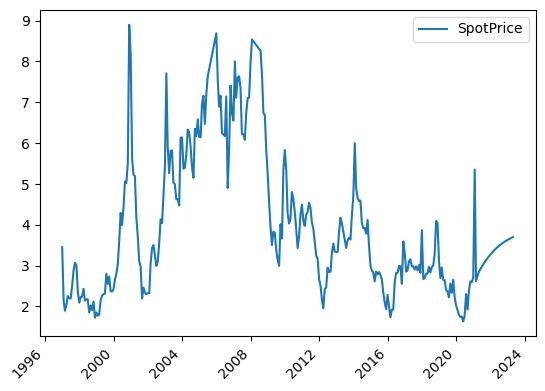

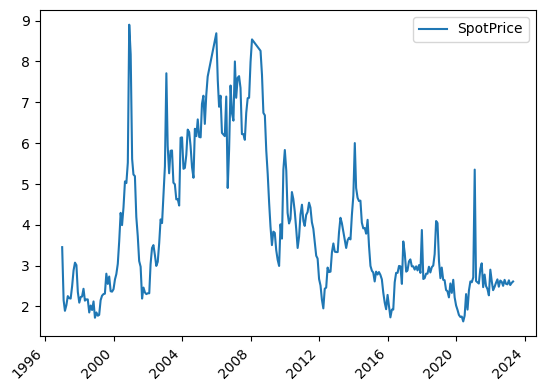

In [332]:
AR_predict.plot()
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()
ARIMA_predict.plot()
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()

Ну тут результат ARIMA, конечно, куда более походит на реалистичный прогноз

Это были краткосрочные прогнозирования, теперь попробуем долгосрочное

In [333]:
AR_long_predict = AR.predict(start=len(df), end=len(df) + 144)
ARIMA_long_predict = ARIMAA.predict(start=len(df), end=len(df) + 144)
AR_long_predict = AR_long_predict.to_frame()
ARIMA_long_predict = ARIMA_long_predict.to_frame()
index_dates = pd.date_range(start='2021-04-01', end='2033-05-01', freq='M')
AR_long_predict['date']=index_dates
ARIMA_long_predict['date']=index_dates
AR_long_predict.set_index('date', inplace=True) 
ARIMA_long_predict.set_index('date', inplace=True) 
AR_long_predict = pd.concat([df,AR_long_predict])
ARIMA_long_predict = pd.concat([df, ARIMA_long_predict])


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\ivans\AppData\Local\Programs\Python\Pytho

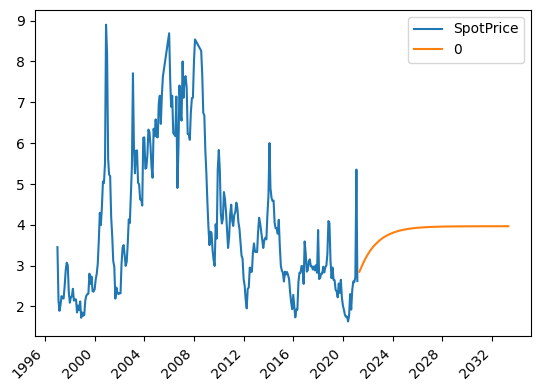

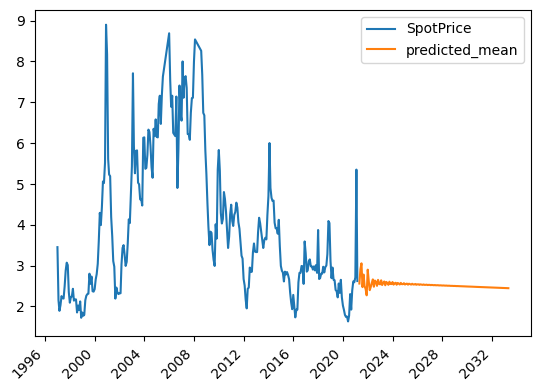

In [334]:
AR_long_predict.plot()
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()
ARIMA_long_predict.plot()
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()

В случае долгосрочной перспективы все выглядит куда более печальнее